# EDA & Data Filtering — GNPS2 Classical Molecular Networking output

### Check of raw `nf_output/`

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)

BASE_DIR = Path("data/MCE-GNPS")   # run this notebook from the repo root
NETWORK_DIR = BASE_DIR / "nf_output" / "networking"

nodes = pd.read_csv(NETWORK_DIR / "clustersummary_with_network.tsv", sep="\t", low_memory=False)
edges = pd.read_csv(NETWORK_DIR / "filtered_pairs.tsv", sep="\t")
components = pd.read_csv(NETWORK_DIR / "component_summary.tsv", sep="\t")

print(f"nodes:      {nodes.shape}")
print(f"edges:      {edges.shape}")
print(f"components: {components.shape}")

### Node table (raw)

- Quick view of the node table columns and rows.
- Check missingness and basic uniqueness of the cluster index.

In [3]:
nodes.head()

,cluster index,number of spectra,parent mass,precursor charge,precursor mass,sum(precursor intensity),RTMean,ATTRIBUTE_GROUP:GNPSGROUP:G1,ATTRIBUTE_GROUP:GNPSGROUP:G2,ATTRIBUTE_ORGANISM:GNPSGROUP:Vibrio_1A01,ATTRIBUTE_ORGANISM:GNPSGROUP:Vibrio_6D03,ATTRIBUTE_ORGANISM:GNPSGROUP:Phaeobacter_B2R04,ATTRIBUTE_ORGANISM:GNPSGROUP:Shewanella_B2R08,ATTRIBUTE_ORGANISM:GNPSGROUP:Roseovarius_B2R09,ATTRIBUTE_ORGANISM:GNPSGROUP:Colwellia_C2M19,ATTRIBUTE_ORGANISM:GNPSGROUP:Paracoccus_C2R07,ATTRIBUTE_ORGANISM:GNPSGROUP:Salipiger_C3M06,ATTRIBUTE_ORGANISM:GNPSGROUP:Acinetobacter_D3M06,ATTRIBUTE_ORGANISM:GNPSGROUP:Arenibacter_D3M17,ATTRIBUTE_ORGANISM:GNPSGROUP:Motilimonas_G1M02,ATTRIBUTE_ORGANISM:GNPSGROUP:nan,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:1-1A01.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:2-6D03.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:3-B2R04.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:4-B2R08.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:5-B2R09.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:6-C2M19.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:7-C2R07_2.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:8-C3M06.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:9-D3M06.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:10-D3M17.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:11-G1M02.mzML,ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:bkgrnd-marine-broth.mzML,ATTRIBUTE_GROUP,ATTRIBUTE_ORGANISM,ATTRIBUTE_PERFILEGROUPING,component,SpectrumID,#Scan#,SpectrumFile,LibraryName,MQScore,TIC_Query,RT_Query,MZErrorPPM,SharedPeaks,MassDiff,SpecMZ,SpecCharge,FileScanUniqueID,NumberHits,Compound_Name,Ion_Source,Instrument,Compound_Source,PI,Data_Collector,Adduct,Precursor_MZ,ExactMass,Charge,CAS_Number,Pubmed_ID,Smiles,INCHI,INCHI_AUX,Library_Class,IonMode,Organism,LibMZ,UpdateWorkflowName,LibraryQualityString,tags,molecular_formula,InChIKey,InChIKey-Planar,superclass,class,subclass,npclassifier_superclass,npclassifier_class,npclassifier_pathway,library_usi
0,1,14,103.053967,1,103.053967,0.0,282.628071,14,0,0,0,0,0,1,3,2,2,3,3,0,0,0,0,0,0,1,3,2,2,3,3,0,0,G1,"Roseovarius_B2R09,Colwellia_C2M19,Paracoccus_C...","5-B2R09.mzML,6-C2M19.mzML,7-C2R07_2.mzML,8-C3M...",7,CCMSLIB00017431222,1.0,specs_ms.mgf,GNPS-ION-MOBILITY-LIBRARY.mgf,0.822599,143550.0,280.762,9363.44,6.0,0.97406,103.054,1.0,temp/specs_ms.mgf1,1.0,3-hydroxybenzaldehyde [CCS=112.9464111328125],LC-ESI,ToF,Crude,Pieter Dorrestein,victoriadeleray,[M+H-H2O]+,104.028,122.037,1.0,NaN,NaN,O=CC1=CC=CC(O)=C1,"InChI=1S/C7H6O2/c8-5-6-2-1-3-7(9)4-6/h1-5,9H",NaN,1.0,Positive,GNPS-ION-MOBILITY-LIBRARY,104.028,UPDATE-SINGLE-ANNOTATED-GOLD,Gold,NaN,C7H6O2,IAVREABSGIHHMO-UHFFFAOYSA-N,IAVREABSGIHHMO,Organic oxygen compounds,Organooxygen compounds,Carbonyl compounds,Phenolic acids (C6-C1),Shikimic acids and derivatives|Simple phenolic...,Shikimates and Phenylpropanoids,mzspec:GNPS:GNPS-LIBRARY:CCMSLIB00017431222
1,2,15,103.053972,1,103.053972,0.0,282.881667,15,0,0,0,0,0,1,3,2,3,3,3,0,0,0,0,0,0,1,3,2,3,3,3,0,0,G1,"Roseovarius_B2R09,Colwellia_C2M19,Paracoccus_C...","5-B2R09.mzML,6-C2M19.mzML,7-C2R07_2.mzML,8-C3M...",7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,6,105.069565,1,105.069565,0.0,316.662833,6,0,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,6,0,0,G1,Arenibacter_D3M17,10-D3M17.mzML,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,36,110.008891,1,110.008891,0.0,106.218194,33,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,"G1,G2","Vibrio_1A01,Vibrio_6D03,Phaeobacter_B2R04,Shew...","1-1A01.mzML,2-6D03.mzML,3-B2R04.mzML,4-B2R08.m...",-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,108,110.008891,1,110.008891,0.0,119.972741,99,9,9,9,9,9,9,9,9,9,9,9,9,0,9,9,9

In [3]:
# How many columns, and what fraction of each is missing/empty?
missing_frac = nodes.isna().mean().sort_values(ascending=False)
missing_frac.head(20)

tags                       0.998561
Pubmed_ID                  0.992806
INCHI_AUX                  0.966906
CAS_Number                 0.938129
npclassifier_class         0.893525
class                      0.889209
superclass                 0.889209
subclass                   0.889209
npclassifier_superclass    0.889209
npclassifier_pathway       0.880576
molecular_formula          0.871942
InChIKey-Planar            0.860432
InChIKey                   0.860432
Smiles                     0.858993
INCHI                      0.858993
Ion_Source                 0.847482
NumberHits                 0.835971
MZErrorPPM                 0.835971
RT_Query                   0.835971
Compound_Name              0.835971
dtype: float64

In [4]:
# cluster index should be unique — one row per node
print("duplicate cluster index rows:", nodes["cluster index"].duplicated().sum())
print("total nodes:", len(nodes))
print("nodes with a component assigned:", nodes["component"].notna().sum())
print("nodes with component == -1 (singleton, no edges):", (nodes["component"] == -1).sum())

duplicate cluster index rows: 0
total nodes: 695
nodes with a component assigned: 695
nodes with component == -1 (singleton, no edges): 213


### Spectra / mass / charge

- Inspect parent mass and precursor charge distributions.
- Look for odd values or unexpected ranges (maybe bad spectrum annotations)

In [5]:
nodes["number of spectra"].describe()

count     695.000000
mean       28.294964
std       111.243525
min         2.000000
25%         3.000000
50%         9.000000
75%        28.500000
max      1956.000000
Name: number of spectra, dtype: float64

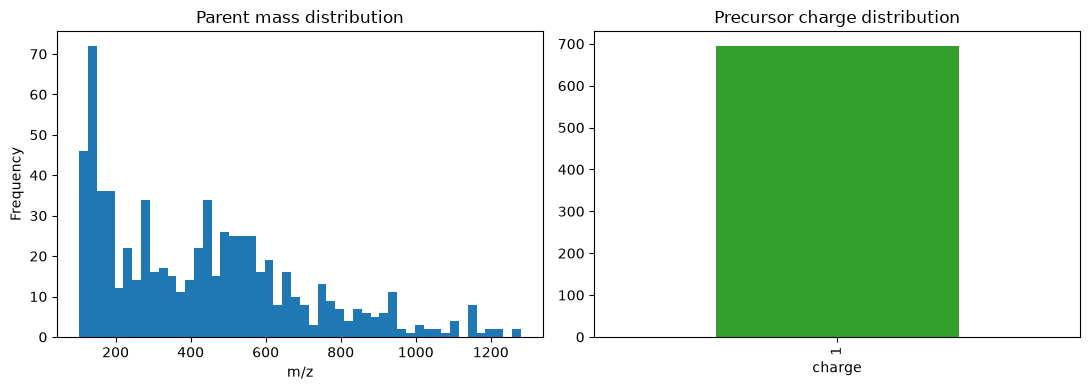

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
nodes["parent mass"].plot(kind="hist", bins=50, ax=axes[0], color="#1f78b4")
axes[0].set_title("Parent mass distribution")
axes[0].set_xlabel("m/z")

nodes["precursor charge"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#33a02c")
axes[1].set_title("Precursor charge distribution")
axes[1].set_xlabel("charge")
plt.tight_layout()
plt.show()

### Library annotations (raw)

- Count how many nodes have library matches.
- Matched vs unmatched

Library-matched nodes: 114 (16.4%)
Unannotated nodes:     581 (83.6%)


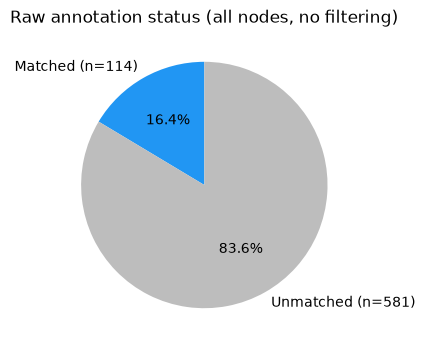

In [4]:
has_match = nodes["Compound_Name"].notna() & (nodes["Compound_Name"] != "")
print(f"Library-matched nodes: {has_match.sum()} ({100*has_match.mean():.1f}%)")
print(f"Unannotated nodes:     {(~has_match).sum()} ({100*(~has_match).mean():.1f}%)")

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(
    [has_match.sum(), (~has_match).sum()],
    labels=[f"Matched (n={has_match.sum()})", f"Unmatched (n={(~has_match).sum()})"],
    autopct="%1.1f%%", startangle=90, colors=["#2196F3", "#BDBDBD"],
)
ax.set_title("Raw annotation status (all nodes, no filtering)")
plt.show()

### Understanding MZError PPM

In [5]:
# MZErrorPPM distribution for matched nodes
nodes.loc[has_match, "MZErrorPPM"].abs().describe()

count      114.000000
mean      2040.304361
std       3517.821576
min          0.000000
25%          1.308418
50%          5.243315
75%       3187.347500
max      16095.400000
Name: MZErrorPPM, dtype: float64

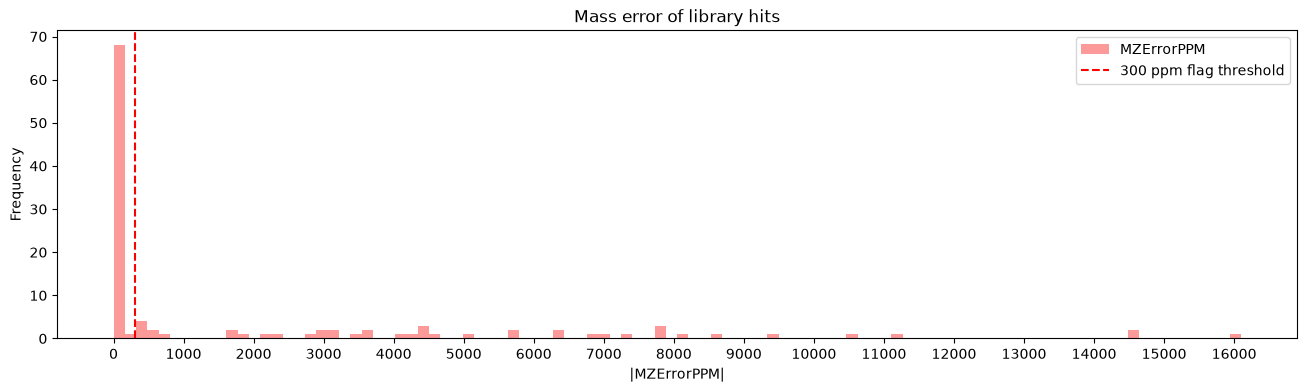

In [6]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(16, 4))
nodes.loc[has_match, "MZErrorPPM"].abs().plot(kind="hist", bins=100, ax=ax, color="#fb9a99")
ax.axvline(300, color="red", linestyle="--", label="300 ppm flag threshold")
ax.set_xlabel("|MZErrorPPM|")
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.set_title("Mass error of library hits")
ax.legend()
plt.show()

### Network structure — degree & component sizes

- Compute node degree and connected component sizes.
- Compare these numbers to what the plotting code shows.
- If numbers look sane but the figure is wrong, the issue is layout or plotting.

In [10]:
G = nx.Graph()
G.add_nodes_from(nodes["cluster index"])
G.add_edges_from(edges[["CLUSTERID1", "CLUSTERID2"]].itertuples(index=False, name=None))

print(f"Graph nodes: {G.number_of_nodes()}")
print(f"Graph edges: {G.number_of_edges()}")

conn_components = list(nx.connected_components(G))
sizes = sorted((len(c) for c in conn_components), reverse=True)
print(f"Connected components: {len(conn_components)}")
print(f"Singletons (size 1): {sum(1 for s in sizes if s == 1)}")
print(f"Largest component size: {sizes[0]}")
print(f"Top 10 component sizes: {sizes[:10]}")

Graph nodes: 695
Graph edges: 928
Connected components: 296
Singletons (size 1): 213
Largest component size: 78
Top 10 component sizes: [78, 30, 28, 21, 18, 18, 18, 17, 17, 15]


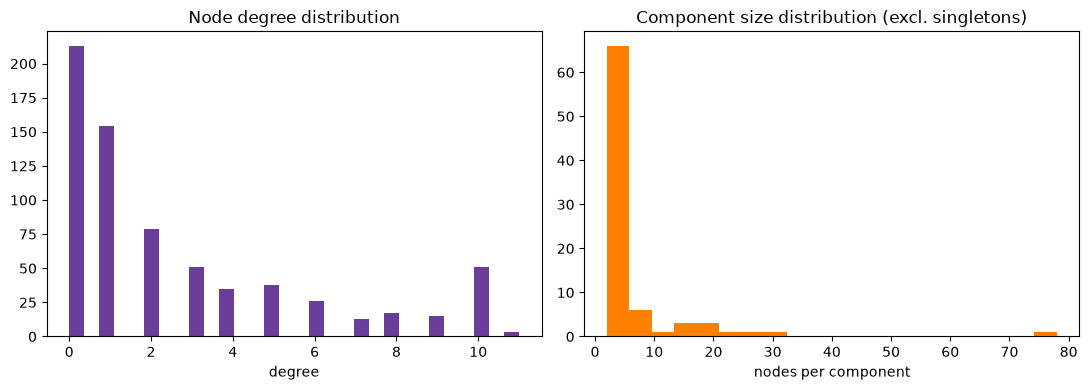

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

degrees = [d for _, d in G.degree()]
axes[0].hist(degrees, bins=30, color="#6a3d9a")
axes[0].set_title("Node degree distribution")
axes[0].set_xlabel("degree")

component_sizes_no_singletons = [s for s in sizes if s > 1]
axes[1].hist(component_sizes_no_singletons, bins=20, color="#ff7f00")
axes[1].set_title("Component size distribution (excl. singletons)")
axes[1].set_xlabel("nodes per component")
plt.tight_layout()
plt.show()

In [12]:
# component_summary.tsv vs what we just computed from filtered_pairs.tsv — should match
components.sort_values("number_of_nodes", ascending=False).head(10)

,component_id,number_of_nodes,number_of_edges
0,7,77,166
1,8,29,103
2,12,27,81
3,3,20,68
4,10,17,66
5,18,17,22
6,1,17,65
7,82,16,62
8,27,16,59
9,22,14,32


### Isolate vs broth coverage 

how many nodes are detected per isolate (raw, no broth subtraction)

In [14]:
isolate_cols = [c for c in nodes.columns if c.startswith("ATTRIBUTE_ORGANISM:GNPSGROUP:") and c != "ATTRIBUTE_ORGANISM:GNPSGROUP:nan"]
broth_col = "ATTRIBUTE_PERFILEGROUPING:GNPSGROUP:bkgrnd-marine-broth.mzML"

coverage = (nodes[isolate_cols] > 0).sum().sort_values(ascending=False)
coverage.index = [c.split(":")[-1] for c in coverage.index]
coverage

Paracoccus_C2R07       352
Salipiger_C3M06        344
Acinetobacter_D3M06    344
Phaeobacter_B2R04      338
Roseovarius_B2R09      337
Arenibacter_D3M17      329
Shewanella_B2R08       295
Colwellia_C2M19        295
Vibrio_6D03            276
Vibrio_1A01            197
Motilimonas_G1M02      192
dtype: int64

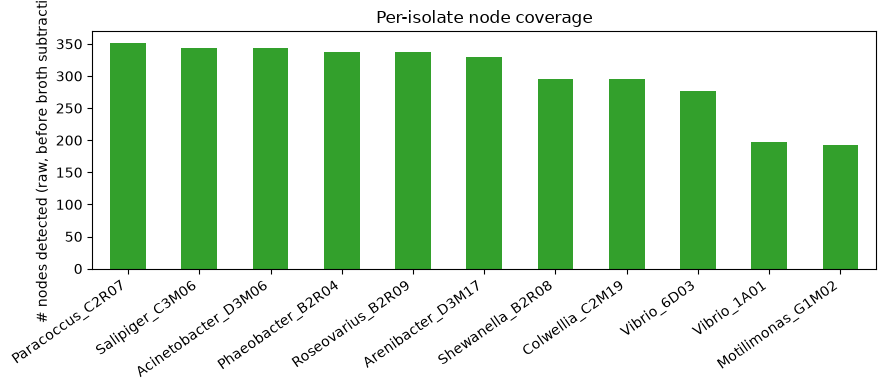

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
coverage.plot(kind="bar", ax=ax, color="#33a02c")
ax.set_ylabel("# nodes detected (raw, before broth subtraction)")
ax.set_title("Per-isolate node coverage")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [16]:
broth_present = nodes[broth_col] > 0
isolate_present = nodes[isolate_cols].sum(axis=1) > 0
print(f"Total nodes:                 {len(nodes)}")
print(f"Broth-only (no isolate):     {(broth_present & ~isolate_present).sum()}")
print(f"Isolate-only (no broth):     {(~broth_present & isolate_present).sum()}")
print(f"Shared (broth + isolate):    {(broth_present & isolate_present).sum()}")
print(f"Neither:                     {(~broth_present & ~isolate_present).sum()}")

Total nodes:                 695
Broth-only (no isolate):     3
Isolate-only (no broth):     445
Shared (broth + isolate):    247
Neither:                     0


to check against `analysis_output/`
- Compare the raw annotation pie to `analysis_output/annotation_status_pie.png`.
    - The script splits out FLAGGED hits (ion-mobility source or >300 ppm mass error) and applies broth subtraction, so expect a smaller "valid" slice in the script output -- flagged hits are kept, just labeled.
- Compare component size distributions to `cmn_piechart_network.png`.
    - If the script plots only components with ≥2 nodes, singletons will be absent by design.
- If the plain spring-layout plot is tangled, focus on layout parameters (`k`, iterations) rather than the graph data.
- `nodes_isolate_only.tsv` / `edges_isolate_only.tsv` (stricter than broth subtraction — excludes shared nodes too) are produced by `01_prelim_data_cleaning.py`, not this notebook. This notebook only computes the raw counts above for a sanity check.